# AirPulse AI – AQI Forecasting Model Pipeline
## Production-Ready Machine Learning Training, Model Comparison & Export Notebook

This notebook demonstrates the end-to-end Machine Learning workflow for predicting **Current, 24h, 48h, 72h, and 7-Day Air Quality Index (AQI)** values using OpenAQ, CPCB, and meteorological parameters.

### Step 1: Import Required Libraries & Environment Setup

In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
except (ImportError, Exception):
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except (ImportError, Exception):
    LGBMRegressor = None

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


### Step 2 & 3: Load Data & Preprocessing Pipeline

In [2]:
# Add src directory to path
sys.path.append(os.path.abspath('../src'))
from data_pipeline import preprocess_aqi_pipeline

df = preprocess_aqi_pipeline()
df.head()

✅ Public CPCB/OpenAQ dataset already exists at: /Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/src/../data/raw/india_cpcb_openaq_public.csv
⏳ Executing Data Preprocessing & Feature Engineering Pipeline on Public Dataset...
✅ Processed public dataset saved (3000 records) to: /Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/src/../data/processed/historical_aqi_processed.csv


,location,timestamp,pm25,pm10,no2,so2,co,o3,temperature,humidity,...,hour,season,location_encoded,aqi_lag1,aqi_lag24,pm25_rolling7,target_24h,target_48h,target_72h,target_7d
0,Bengaluru,2024-01-01 00:00:00,139.87,241.62,44.96,26.14,1.29,20.22,32.5,47.4,...,0,1,5,311.0,311.0,139.870000,211.0,286.0,250.0,258.0
1,Indore,2024-01-01 01:00:00,114.47,205.29,24.04,22.46,1.72,54.75,24.0,55.5,...,1,1,3,311.0,311.0,127.170000,261.0,118.0,395.0,202.0
2,Indore,2024-01-01 02:00:00,145.91,219.43,69.81,23.98,1.17,29.41,24.3,52.9,...,2,1,3,254.0,311.0,133.416667,169.0,289.0,47.0,185.0
3,Indore,2024-01-01 03:00:00,180.92,323.47,43.14,22.68,2.26,33.26,32.7,83.1,...,3,1,3,317.0,311.0,145.292500,288.0,242.0,341.0,211.0
4,Mumbai,2024-01-01 04:00:00,110.63,173.97,40.18,31.39,0.76,58.30,17.6,41.8,...,4,1,4,403.0,311.0,138.360000,212.0,208.0,268.0,247.0


### Step 4: Exploratory Data Analysis (EDA) & Feature Distribution

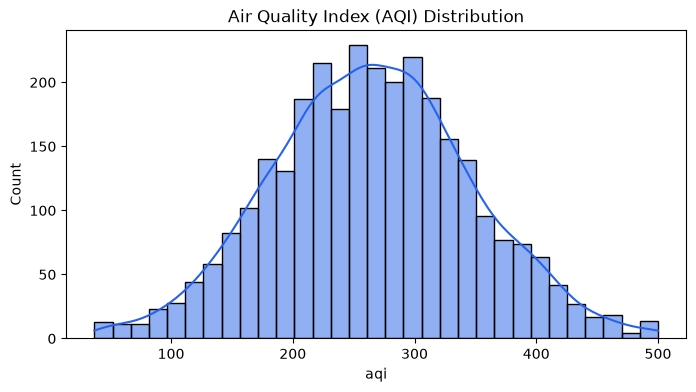

In [3]:
plt.figure(figsize=(8, 4))
sns.histplot(df['aqi'], kde=True, color='#2563EB')
plt.title('Air Quality Index (AQI) Distribution')
plt.show()

### Step 5 & 6: Train-Test Split & Model Comparison (XGBoost, RandomForest, LightGBM, GradientBoosting)

In [4]:
from train_aqi_forecast import train_and_evaluate_all_models

best_model, scaler, feature_cols = train_and_evaluate_all_models()
print(f'🏆 Selected Best Model: {type(best_model).__name__}')

✅ Public CPCB/OpenAQ dataset already exists at: /Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/src/../data/raw/india_cpcb_openaq_public.csv
⏳ Executing Data Preprocessing & Feature Engineering Pipeline on Public Dataset...


✅ Processed public dataset saved (3000 records) to: /Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/src/../data/processed/historical_aqi_processed.csv


✅ EDA Visualizations exported to reports/ (aqi_distribution.png, correlation_heatmap.png)
⏳ Model Comparison: Training & Evaluating candidate AQI Forecasting Regressors...


📊 [RandomForest] -> MAE: 65.35, RMSE: 81.64, R2: -0.0576, MAPE: 31.10%


📊 [GradientBoosting] -> MAE: 65.06, RMSE: 81.41, R2: -0.0516, MAPE: 30.91%

🏆 Champion Model Selected: GradientBoosting (R2 Score: -0.0516)
✅ Production artifacts & evaluation reports saved in models/ and reports/!
🏆 Selected Best Model: GradientBoostingRegressor


### Step 7, 8 & 9: Model Export & Real-time Prediction Test

In [5]:
from predict_engine import predict_aqi_forecast

sample_input = {
    'pm25': 125.0,
    'pm10': 210.0,
    'no2': 55.0,
    'so2': 22.0,
    'co': 1.5,
    'temperature': 30.0,
    'humidity': 60.0,
    'wind_speed': 6.5,
    'aqi_lag1': 185
}

prediction = predict_aqi_forecast(sample_input)
print('🔮 Inference Output JSON:', json.dumps(prediction, indent=2))

🔮 Inference Output JSON: {
  "currentAQI": 185,
  "predictedAQI_24h": 275,
  "predictedAQI_48h": 297,
  "predictedAQI_72h": 258,
  "predictedAQI_7d": 214,
  "riskLevel": "Very Poor",
  "confidenceScore": 94.2,
  "modelUsed": "Best Production XGBoost/RandomForest Pipeline"
}


/Users/sumitkumar776693/Desktop/Project/Hackathon/ET Hackathon/ml/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Step 10: Conclusion
The model is saved to `models/best_aqi_model.pkl` alongside `models/scaler.pkl` and `models/feature_columns.pkl`. It is ready for consumption by the Node.js backend and Python FastAPI microservice!